# Lab 01: Data wrangling and EDA

**You should add this to a personal Github repo and submit the link to the repo in Canvas.** Add your name to the top of this document and anyone you worked with.

The goal of this lab is to practice working with datasets using Pandas and explore a dataset with plotting and basic statistics. In particular, we will look at a plot to track flows (association between two categoricals): the alluvial diagram.

Here is your lab prompt: You are advising the University of Virginia’s Office of Development on opportunities to expand philanthropic support from international sources. Using the foreign-giving data provided, develop a short strategic plan identifying the countries, institutions, or donor segments UVA should prioritize for future engagement.

Your recommendations should be evidence-based. Use the data to identify patterns in giving, compare potential sources of support, and explain why particular markets or institutions appear especially promising. Support your conclusions with appropriate summaries and visualizations, and translate your findings into a small set of concrete recommendations for the Director of Development.,

1. In your first .ipynb or .py file called **initial_analysis** complete the following steps:
     1. Load the Foreign Gifts data.
     2. Describe the differences between different classes of gift types.
     3. Answer the following questions:
         1. Which country gives the most money in total?
         2. Which country initiates the most gifts by count?
         3. Which country gives the largest gifts on average?
         4. Which institution receive the most money in total?
         5. Which institution receive the greatest number of gifts by count?
         6. What is the average amount each university receives? Median amount? If they are different why?
         7. What is the largest flow of a single country to a single institution?
         8. Which are the top giftors to US academic institutions?
 2. In a new .ipynb/.py file called **uva_analysis**, analyze foreign giving to UVA. Compare UVA to appropriate peer institutions and the market overall. Propose a strategy for finding new sources of foreign money and provide a quantitative analysis.
 3. In a document file (.doc, .docx, .pdf, etc.), summarize your findings:
     1. Executive Summary: What are your main findings and recommendations, in a single paragraph?
     2. Summarize the results of your initial analyses of overall giving and giving to UVA (1-3 paragraphs).
     3. Describe a strategy for finding new potential sources of money for UVA. What countries or institutions should UVA target, and why? (1-3 paragraphs)
     4. Conclude with a summary of UVA's prospects for increasing foreign giving. (1 paragraph).

 In total, your submission repo contain submit at least .ipynb/.py analysis files and a document file with your report (.doc, .docx, .pdf, etc.). If you divide the work among members of a group, make sure that you understand the code being written and submitted by the other members of your group.



## The standard stack: importing packages + reading in the data

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('ForeignGifts_edu.csv',low_memory=False)
df.head()

/opt/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
0,1,102000,Jacksonville State University,Jacksonville,AL,43738,250000,Monetary Gift,CHINA,NaN
1,2,104700,Troy University,Troy,AL,43592,463657,Contract,CHINA,Confucius Institute Headquarters
2,3,105100,University of Alabama,Tuscaloosa,AL,43466,3649107,Contract,ENGLAND,Springer Nature Customer Service Ce
3,4,105100,University of Alabama,Tuscaloosa,AL,43472,1000,Contract,SAUDI ARABIA,Saudi Arabia Education Mission
4,5,105100,University of Alabama,Tuscaloosa,AL,43479,49476,Contract,SAUDI ARABIA,Saudi Arabia Education Mission


In [5]:
df['Gift Type'].unique()

<ArrowStringArray>
['Monetary Gift', 'Contract', 'Real Estate']
Length: 3, dtype: str

## 2 Differences in Classes of Gift Types

There are three different classes of gift types. 1. Monetary Gift, Contract and Real Estate.

A monetary gift is a voluntary donation from a foreign country without any requirements of where the university should allocate the money. 

A contract requires a direct exchange of services for that payment. This could be the allocation of the money, a service or a specific deliverable.

Real Estate is the purchase of property or physical land. One example could be a foreign country providing money for a specific new building.



## Groupby

As we learned, `.groupby` is a super useful way to aggregate the data and explore summary statistics. We can assign the output to a new dataframe, just taking the n largest amounts. Resetting the index just changes the index to integers starting at 0. 

<div class="alert alert-block alert-warning">
<b>Question 1:</b>  Which country gives the most money, in total?
</div>


In [12]:
#1. Question 1
country_totals = (
    df.groupby("Country of Giftor")["Foreign Gift Amount"]
.sum()
.nlargest(1)
.reset_index()
)

country_totals

,Country of Giftor,Foreign Gift Amount
0,QATAR,2706240869


<div class="alert alert-block alert-warning">
<b>Question 2:</b>  Which country initiates the most gifts, by count?
</div>


In [13]:
#2. Question 2
country_gifts_counts = (
    df.groupby("Country of Giftor")["Foreign Gift Amount"]
        .size() 
        .nlargest(1)
        .reset_index(name="Gift Count")
    
)
country_gifts_counts


,Country of Giftor,Gift Count
0,ENGLAND,3655


<div class="alert alert-block alert-warning">
<b>Question 3:</b>  Which country gives the largest gifts, on average?
</div>

In [14]:
country_average_gifts = (
    df.groupby("Country of Giftor")["Foreign Gift Amount"]
        .mean()
        .nlargest(1)
        .reset_index(name="Average Gift Amount")
    
)
country_average_gifts

,Country of Giftor,Average Gift Amount
0,BERMUDA,7.688837e+06


## Ordering by institution

<div class="alert alert-block alert-warning">
<b>Question 4:</b>  Which institution receive the most money, in total?
</div>

<div class="alert alert-block alert-warning">
<b>Question 5:</b>  Which institution receive the greatest number of gifts, by count?
</div>

Build a plot of the top 20 institutions by the amount or number of gifts they have received using either seaborn or plotly. 

In [17]:
#Question 4
institution_totals = (
    df.groupby("Institution Name")["Foreign Gift Amount"]
.sum()
.nlargest(1)
.reset_index(name="Total Gift Amount")
)

institution_totals

,Institution Name,Total Gift Amount
0,Carnegie Mellon University,1477922504


In [18]:
institution_gift_counts = (
    df.groupby("Institution Name")
.size()
.nlargest(1)
.reset_index(name="Gift Count")
)

institution_gift_counts

,Institution Name,Gift Count
0,"University of California, Los Angeles",3916


## Comparing summary statistics

<div class="alert alert-block alert-warning">
<b>Question 6:</b>  What is the average amount each university receives? Median amount? If they are different, why?
</div>

Plot a histogram of the amounts received by each university, and then label the median and the mean as vertical lines.


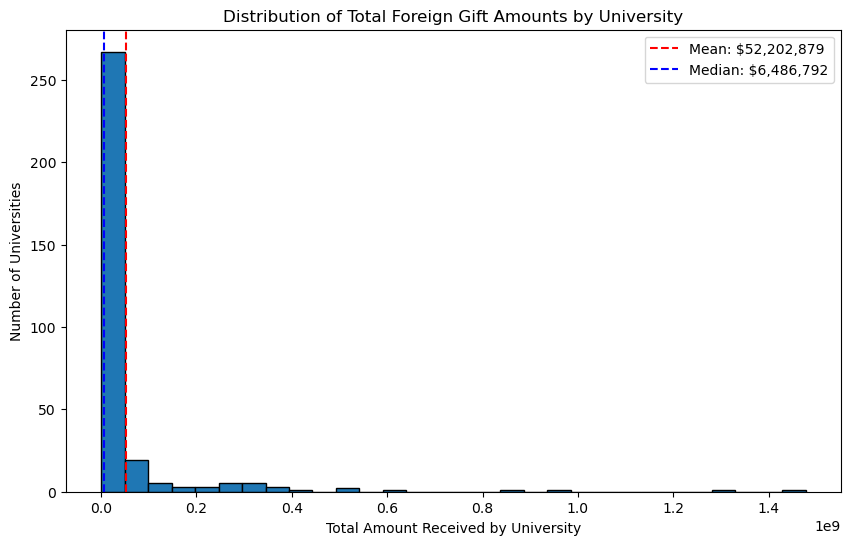

In [24]:
#Question 6
university_totals = (
    df.groupby("Institution Name")["Foreign Gift Amount"]
        .sum()
)

mean_amount = university_totals.mean()
median_amount = university_totals.median()

plt.figure(figsize=(10, 6))
plt.hist(university_totals, bins=30, edgecolor="black")

plt.axvline(mean_amount, color="red", linestyle="--",
            label=f"Mean: ${mean_amount:,.0f}")
plt.axvline(median_amount, color="blue", linestyle="--",
            label=f"Median: ${median_amount:,.0f}")

plt.xlabel("Total Amount Received by University")
plt.ylabel("Number of Universities")
plt.title("Distribution of Total Foreign Gift Amounts by University")
plt.legend()
plt.show()

## Relationship between variables: 
<div class="alert alert-block alert-warning">
<b>Question 7:</b>  What is the largest flow of a single country to a single institution?
</div>

### Cross-tabulation
First, use `pd.crosstab` to look at the relationship between outcoming gifts from countries and incoming gifts to institutions. 

In [ ]:
#Question 7
flow_table = pd.crosstab(
    index=df["Country of Giftor"],
    columns=df["Institution Name"],
    values=df["Foreign Gift Amount"],
    aggfunc="sum"
).fillna(0)

largest_flow = (
    flow_table.stack()
    .nlargest(1)
    .reset_index(name="Total Gift Amount")
)

largest_flow

,Country of Giftor,Institution Name,Total Gift Amount
0,QATAR,Cornell University,1.018473e+09


### Flow of information using alluvial plots

To better visualize which countries money is flowing from and which institutions it is flowing into, we can use an alluvial diagram. There is a built-in version in plotly that we'll use.

<div class="alert alert-block alert-warning">
<b>Question 8:</b>  Which are the top giftors to US academic institutions?
</div>

In [26]:
top_giftors = (
    df.groupby("Country of Giftor")["Foreign Gift Amount"]
        .sum()
        .nlargest(10)
        .reset_index(name="Total Gift Amount")
)

top_giftors

,Country of Giftor,Total Gift Amount
0,QATAR,2706240869
1,ENGLAND,1464906771
2,CHINA,1237952112
3,SAUDI ARABIA,1065205930
4,BERMUDA,899593972
5,CANADA,898160656
6,HONG KONG,887402529
7,JAPAN,655954776
8,SWITZERLAND,619899445
9,INDIA,539556490


<div class="alert alert-block alert-warning">
<b>Bonus:</b>  Plot the flows from giftors to institutions. 
</div>


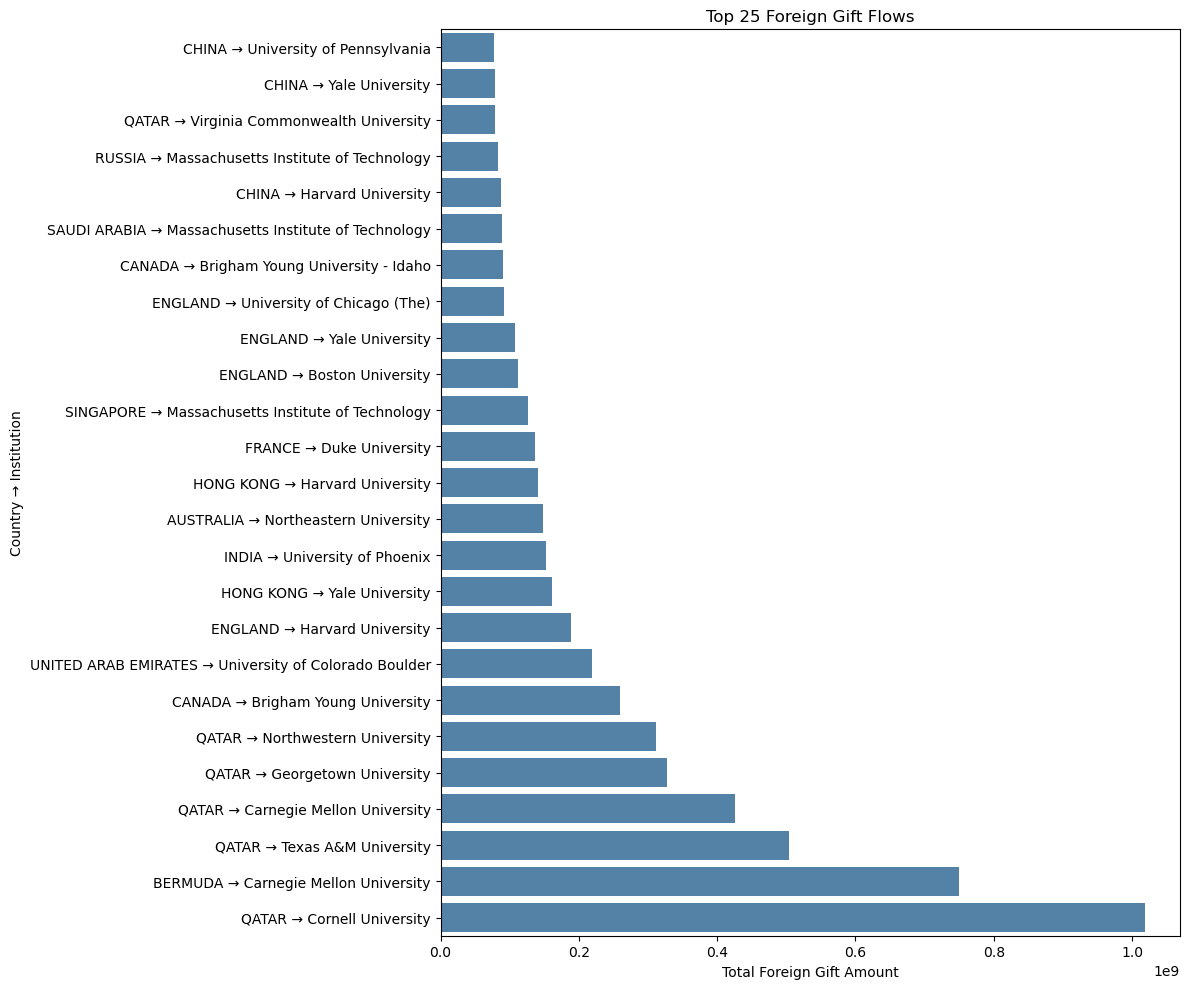

In [6]:
flows = (
    df.groupby(["Country of Giftor", "Institution Name"])["Foreign Gift Amount"]
    .sum()
    .nlargest(25)
    .reset_index()
)

flows["Flow"] = (
    flows["Country of Giftor"] + " → " + flows["Institution Name"]
)

plt.figure(figsize=(12, 10))
sns.barplot(
    data=flows.sort_values("Foreign Gift Amount"),
    x="Foreign Gift Amount",
    y="Flow",
    color="steelblue"
)

plt.xlabel("Total Foreign Gift Amount")
plt.ylabel("Country → Institution")
plt.title("Top 25 Foreign Gift Flows")
plt.tight_layout()
plt.show()

To better visualize which countries money is flowing from and which institutions it is flowing into, we can use an **alluvial diagram**. There is a built-in version in the `plotly` package that we'll use:

In [29]:
import pandas as pd
import plotly.graph_objects as go

df = pd.read_csv('ForeignGifts_edu.csv',low_memory=False)
df.head()

#giftor = 'Giftor Name'
giftor = 'Country of Giftor'
recipi = 'Institution Name'
flow = 'Foreign Gift Amount'
N = 25

flows = (
    df.groupby([giftor, 
                recipi])
      [flow]
      .sum()
      .nlargest(N)
      .reset_index()
)

labels = (
    flows[giftor].tolist()
    + flows[recipi].tolist()
)

labels = list(dict.fromkeys(labels))

fig = go.Figure(
    go.Sankey(
        node=dict(label=labels),
        link=dict(
            source=flows[giftor]
                        .map(labels.index),
            target=flows[recipi]
                        .map(labels.index),
            value=flows[flow]
        )
    )
)

fig.show()